# Volume Under a Surface: 2D Riemann Sums

**This notebook is self-contained; it recaps Riemann sums and surfaces before combining them.**

Everything so far integrated a curve to get an **area**. Nothing forces the idea to stop at one
dimension. Given a surface $z = f(x,y)$ from §3.6, the same construction — chop, approximate, add —
gives the **volume** underneath.

The rectangles become boxes, the single sum becomes a double sum, and nothing else changes.

## Learning objectives

- Extend the Riemann sum to two variables to approximate a **volume**.
- Write a **double integral** and read it as a nested sum.
- Watch the approximation converge as the grid gets finer.

## Background

Chop the $x$ range into pieces of width $\Delta x$ and the $y$ range into pieces of height $\Delta y$.
That divides the base into a grid of small rectangles, each with area $\Delta x\,\Delta y$. Over each
one, stand a box whose height is the surface's value there. The box's volume is

$$f(x_i, y_j)\,\Delta x\,\Delta y$$

Add them all up and you have a **2D Riemann sum**; take the limit as both spacings shrink and you have
the **double integral**:

$$\iint_R f(x,y)\,dA = \lim_{\Delta x,\Delta y \to 0} \sum_i \sum_j f(x_i, y_j)\,\Delta x\,\Delta y$$

A practical warning: the number of boxes grows as $n^2$. Ten times finer in each direction means **one
hundred times** the work. In higher dimensions this gets rapidly worse, which is why high-dimensional
integrals are done by random sampling instead — the Monte Carlo methods of Unit 4.

## This notebook covers

1. The surface and its base grid.
2. Boxes under the surface.
3. Convergence as the grid refines.
4. The cost of a dimension.

**Prerequisites:** `U3-8_Integrals-1_RiemannSums`, `U3-6_Multivariable-1_Surface3D`

**Dataset:** none — a known function, so the exact volume is available.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from mpl_toolkits.mplot3d import Axes3D     # noqa: F401

## 1. The surface

Use $f(x, y) = 2 + \sin(x)\cos(y)$ over $[0, \pi] \times [0, \pi]$ — kept above zero so "volume" is
unambiguous.

Its exact volume can be found by integrating one variable at a time:
$\iint (2 + \sin x \cos y)\,dA = 2\pi^2 + 0 = 2\pi^2 \approx 19.739$, since $\int_0^\pi \cos y\,dy = 0$.
That known value is the target.

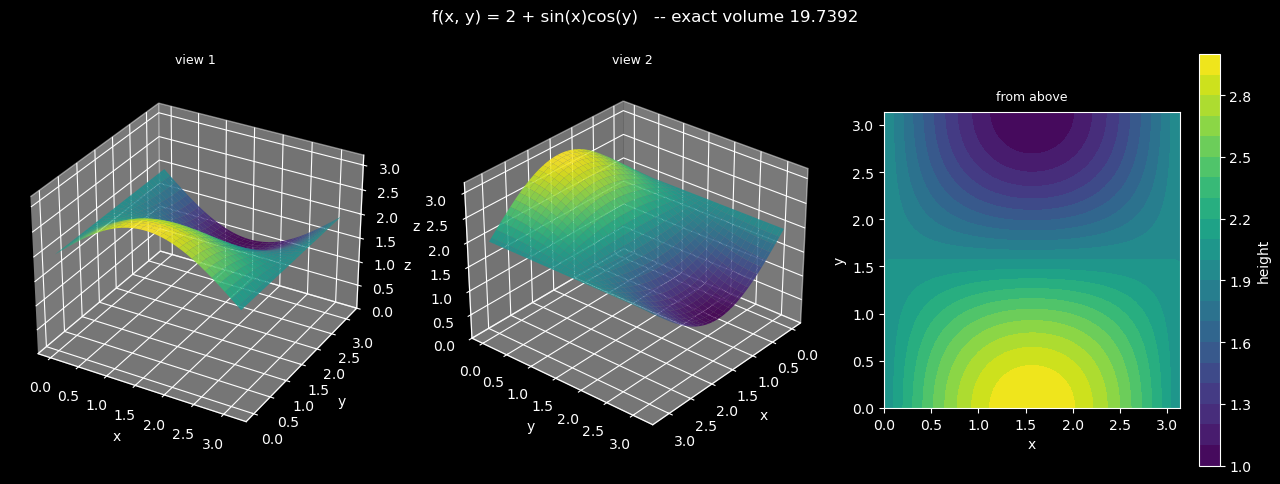

In [2]:
def f(x, y):
    return 2 + np.sin(x)*np.cos(y)

x_lo, x_hi = 0.0, np.pi
y_lo, y_hi = 0.0, np.pi
exact = 2 * np.pi**2

n = 60
xs = np.linspace(x_lo, x_hi, n)
ys = np.linspace(y_lo, y_hi, n)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)

fig = plt.figure(figsize=(13, 4.8))
for k, (elev, azim) in enumerate([(30, -60), (30, 40)]):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none", alpha=0.9)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_zlim(0, 3.2)
    ax.set_title(f"view {k+1}", pad=8, fontsize=9)

ax = fig.add_subplot(1, 3, 3)
cs = ax.contourf(X, Y, Z, levels=20, cmap="viridis")
fig.colorbar(cs, ax=ax, label="height")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
ax.set_title("from above", pad=8, fontsize=9)

plt.suptitle(f"f(x, y) = 2 + sin(x)cos(y)   -- exact volume {exact:.4f}", y=1.0)
plt.tight_layout()
plt.show()

## 2. Boxes under the surface

Divide the base into a grid and stand a box on each cell. The boxes below use the value at each cell's
**corner** — the 2D version of the left rule.

The drawing is vectorized into a single `bar3d` call rather than one call per box, which matters once
the grid gets past a few hundred cells.

In [3]:
def riemann_2d(f, x_lo, x_hi, y_lo, y_hi, n):
    # left-corner rule: sample at the lower-left corner of each cell
    xe = np.linspace(x_lo, x_hi, n + 1)
    ye = np.linspace(y_lo, y_hi, n + 1)
    dx = (x_hi - x_lo) / n
    dy = (y_hi - y_lo) / n
    XC, YC = np.meshgrid(xe[:-1], ye[:-1])
    heights = f(XC, YC)
    return np.sum(heights) * dx * dy, XC, YC, heights, dx, dy

for n in [4, 8, 20, 100]:
    vol, *_ = riemann_2d(f, x_lo, x_hi, y_lo, y_hi, n)
    print(f"n = {n:4d} per side ({n*n:6,d} boxes) -> volume ~ {vol:9.5f}   "
          f"(exact {exact:.5f}, off by {abs(vol-exact):.5f})")

n =    4 per side (    16 boxes) -> volume ~  21.22842   (exact 19.73921, off by 1.48921)
n =    8 per side (    64 boxes) -> volume ~  20.51449   (exact 19.73921, off by 0.77528)
n =   20 per side (   400 boxes) -> volume ~  20.05272   (exact 19.73921, off by 0.31351)
n =  100 per side (10,000 boxes) -> volume ~  19.80204   (exact 19.73921, off by 0.06283)


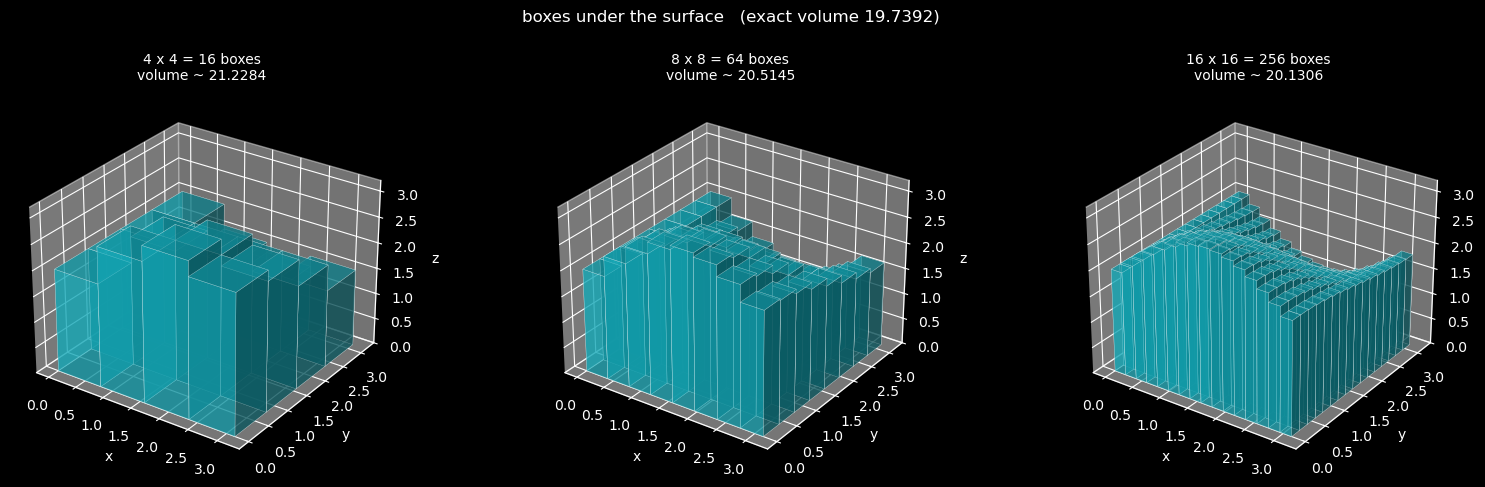

In [4]:
fig = plt.figure(figsize=(16, 4.8))
for k, n in enumerate([4, 8, 16]):
    vol, XC, YC, H, dx, dy = riemann_2d(f, x_lo, x_hi, y_lo, y_hi, n)
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    # one vectorized bar3d call, not one per box
    ax.bar3d(XC.ravel(), YC.ravel(), np.zeros(H.size),
             dx, dy, H.ravel(), color="tab:cyan", alpha=0.55,
             edgecolor="white", linewidth=0.25, shade=True)
    ax.view_init(elev=28, azim=-55)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_zlim(0, 3.2)
    ax.set_title(f"{n} x {n} = {n*n} boxes\nvolume ~ {vol:.4f}", pad=8, fontsize=10)
plt.suptitle(f"boxes under the surface   (exact volume {exact:.4f})", y=1.0)
plt.tight_layout()
plt.show()

## 3. Convergence

Same story as one dimension: finer grid, better answer. On log-log axes the error falls at a steady
rate, and the corner rule converges like $1/n$ — the 2D analogue of the left rule's behaviour in
§3.8-1.

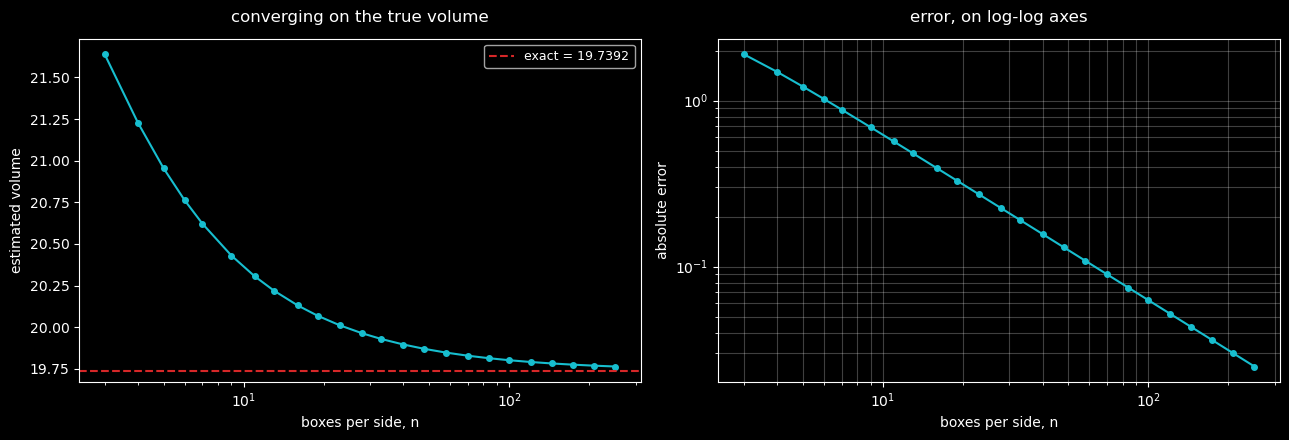

measured convergence slope: -0.99  -> error falls like 1/n


In [5]:
ns = np.unique(np.logspace(0.5, 2.4, 25).astype(int))
vols = np.array([riemann_2d(f, x_lo, x_hi, y_lo, y_hi, n)[0] for n in ns])
errs = np.abs(vols - exact)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].semilogx(ns, vols, "o-", color="tab:cyan", markersize=4)
axes[0].axhline(exact, color="tab:red", ls="--", label=f"exact = {exact:.4f}")
axes[0].set_xlabel("boxes per side, n"); axes[0].set_ylabel("estimated volume")
axes[0].legend(fontsize=9)
axes[0].set_title("converging on the true volume", pad=12)

axes[1].loglog(ns, errs, "o-", color="tab:cyan", markersize=4)
axes[1].set_xlabel("boxes per side, n"); axes[1].set_ylabel("absolute error")
axes[1].grid(alpha=0.25, which="both")
axes[1].set_title("error, on log-log axes", pad=12)

plt.tight_layout()
plt.show()

slope = np.polyfit(np.log10(ns), np.log10(errs), 1)[0]
print(f"measured convergence slope: {slope:.2f}  -> error falls like 1/n")

## 4. The cost of a dimension

Here is the sting. In 1D, $n$ rectangles. In 2D, $n^2$ boxes. In $d$ dimensions, $n^d$ — so the work
explodes as dimensions are added. This is the **curse of dimensionality**, and it is why nobody
integrates a 20-dimensional function on a grid.

The standard escape is to stop using a grid and **sample randomly** instead — Monte Carlo integration,
whose error depends on the number of samples but *not* on the dimension. That is where Unit 4 picks up,
with `MCSampling_CalculateIntegral`.

In [6]:
n = 100
print(f"with n = {n} divisions per dimension:\n")
print(f"{'dimensions':>11} {'evaluations needed':>22}")
print("-" * 36)
for d in range(1, 8):
    print(f"{d:>11} {n**d:22,d}")
print("-" * 36)
print("\nAt roughly a million evaluations per second, 4 dimensions takes seconds")
print("and 7 dimensions takes over 30 years. Grids do not scale.")

with n = 100 divisions per dimension:

 dimensions     evaluations needed
------------------------------------
          1                    100
          2                 10,000
          3              1,000,000
          4            100,000,000
          5         10,000,000,000
          6      1,000,000,000,000
          7    100,000,000,000,000
------------------------------------

At roughly a million evaluations per second, 4 dimensions takes seconds
and 7 dimensions takes over 30 years. Grids do not scale.


## 5. Summary

- The Riemann construction extends directly: **rectangles become boxes**, one sum becomes two, and
  the result is a **volume**.
- $\iint_R f\,dA = \lim \sum_i\sum_j f(x_i,y_j)\,\Delta x\,\Delta y$ — a nested sum in the limit.
- Convergence works the same way, with the corner rule falling like $1/n$.
- **The work grows as $n^d$.** Grid-based integration collapses beyond a few dimensions — the curse of
  dimensionality — and random sampling is the way out (Unit 4).

Next, and last in this unit: approximating an entire function by a polynomial, and finally explaining
where §3.4's error rates came from (`U3-9_Taylor-1_PolynomialApproximation`).